In [1]:
from typing import Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage,AIMessage,BaseMessage
from langgraph.graph import StateGraph, START,END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt,Command
from dotenv import load_dotenv
from typing import Annotated,TypedDict

d:\LangGraph\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model = "llama-3.1-8b-instant"
)

In [4]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [16]:
def chat_node(state: ChatState):
    decision = interrupt(
        {
            "type": "approval",
            "reason": "Model is about to answer a question. Do you approve?",
            "question": state["messages"][-1].content,
            "instruction": "Please respond with 'yes' to approve or 'no' to reject."
        }
    )

    # 🔍 Debug (optional but helpful)
    print("Decision:", decision)

    # ✅ Handle both cases (string OR dict)
    if isinstance(decision, dict):
        approved = decision.get("approved")
    else:
        approved = decision  # assume it's "yes"/"no"

    if approved == "no":
        return {
            "messages": [
                AIMessage(content="Sorry, I cannot answer that question without approval.")
            ]
        }
    else:
        response = model.invoke(state["messages"])
        return {"messages": [response]}

In [17]:
builder = StateGraph(ChatState)

builder.add_node("Chat Node", chat_node)

builder.add_edge(START, "Chat Node")
builder.add_edge("Chat Node", END)

checkpointer = MemorySaver()

app = builder.compile(checkpointer=checkpointer)

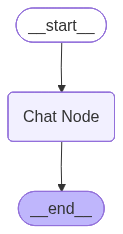

In [7]:
app


In [18]:
## Create a thread id for the conversation
config = {"configurable":{"thread_id":"conversation_1"}}

# Step 1: User sends a message
initial_input = {
    "messages":[
    
        ("user","Explain the gradient deescent algorithm.")
    ]
}

# invoke the app for the first time
result = app.invoke(initial_input, config = config)

In [9]:
result

{'messages': [HumanMessage(content='Explain the gradient deescent algorithm.', additional_kwargs={}, response_metadata={}, id='a46f9abc-ac32-4df6-886b-ef6cd15db4bf')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a question. Do you approve?', 'question': 'Explain the gradient deescent algorithm.', 'instruction': "Please respond with 'yes' to approve or 'no' to reject."}, id='69cf71307098efbc9bb4647ad6fcb132')]}

In [10]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a question. Do you approve?',
 'question': 'Explain the gradient deescent algorithm.',
 'instruction': "Please respond with 'yes' to approve or 'no' to reject."}

In [11]:
user_input = input(f"\nBackend message - {message}\n approval (yes/no): ")

In [19]:
# resume the graph with approval decision 
final_result = app.invoke(
    Command (resume = {"approved": user_input}),
    config = config
)

Decision: {'approved': 'yes'}


In [20]:
print (final_result)

{'messages': [HumanMessage(content='Explain the gradient deescent algorithm.', additional_kwargs={}, response_metadata={}, id='ef1077fe-21f6-42eb-b8da-c5cae790bfab'), AIMessage(content='**Gradient Descent Algorithm**\n=====================================\n\nGradient Descent is a popular optimization algorithm used to minimize the cost function in supervised learning problems, such as linear regression, logistic regression, and neural networks. The algorithm iteratively adjusts the model parameters to reduce the cost function until convergence.\n\n**How Gradient Descent Works**\n-----------------------------\n\n1. **Initialize Model Parameters**: The algorithm starts with an initial set of model parameters (weights and biases).\n2. **Compute Gradient**: The gradient of the cost function is computed with respect to each model parameter. The gradient represents the direction of the steepest ascent of the cost function.\n3. **Update Model Parameters**: The model parameters are updated by 